<a href="https://colab.research.google.com/github/MEHERDIL/polynomial_regression/blob/main/Topic_38_jan_26_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Car Acceptability Assessment Using Multi-Criteria Decision Analysis and Machine Learning**

## **Importing Libraries**
In this cell, I import the essential libraries. I am adding time to measure performance speed and roc_curve from sklearn to visualize the trade-off between sensitivity and specificity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, label_binarize
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score, roc_curve, auc)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Set visualization style
sns.set(style="whitegrid")
%matplotlib inline

# **Loading the Dataset**
I define the column names manually since the UCI source file is headerless. I then read the data directly from the repository into a pandas DataFrame

In [6]:
# Column names based on UCI documentation
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
df = pd.read_csv(url, names=columns)

# Display the dataset structure
print("Dataset Loaded Successfully. Shape:", df.shape)
df.head()

Dataset Loaded Successfully. Shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


# **Exploratory Data Analysis (EDA)**
I perform EDA to visualize how the car attributes are distributed. I create high-quality plots to see if there is any class imbalance and how features like 'Safety' impact the final decision.

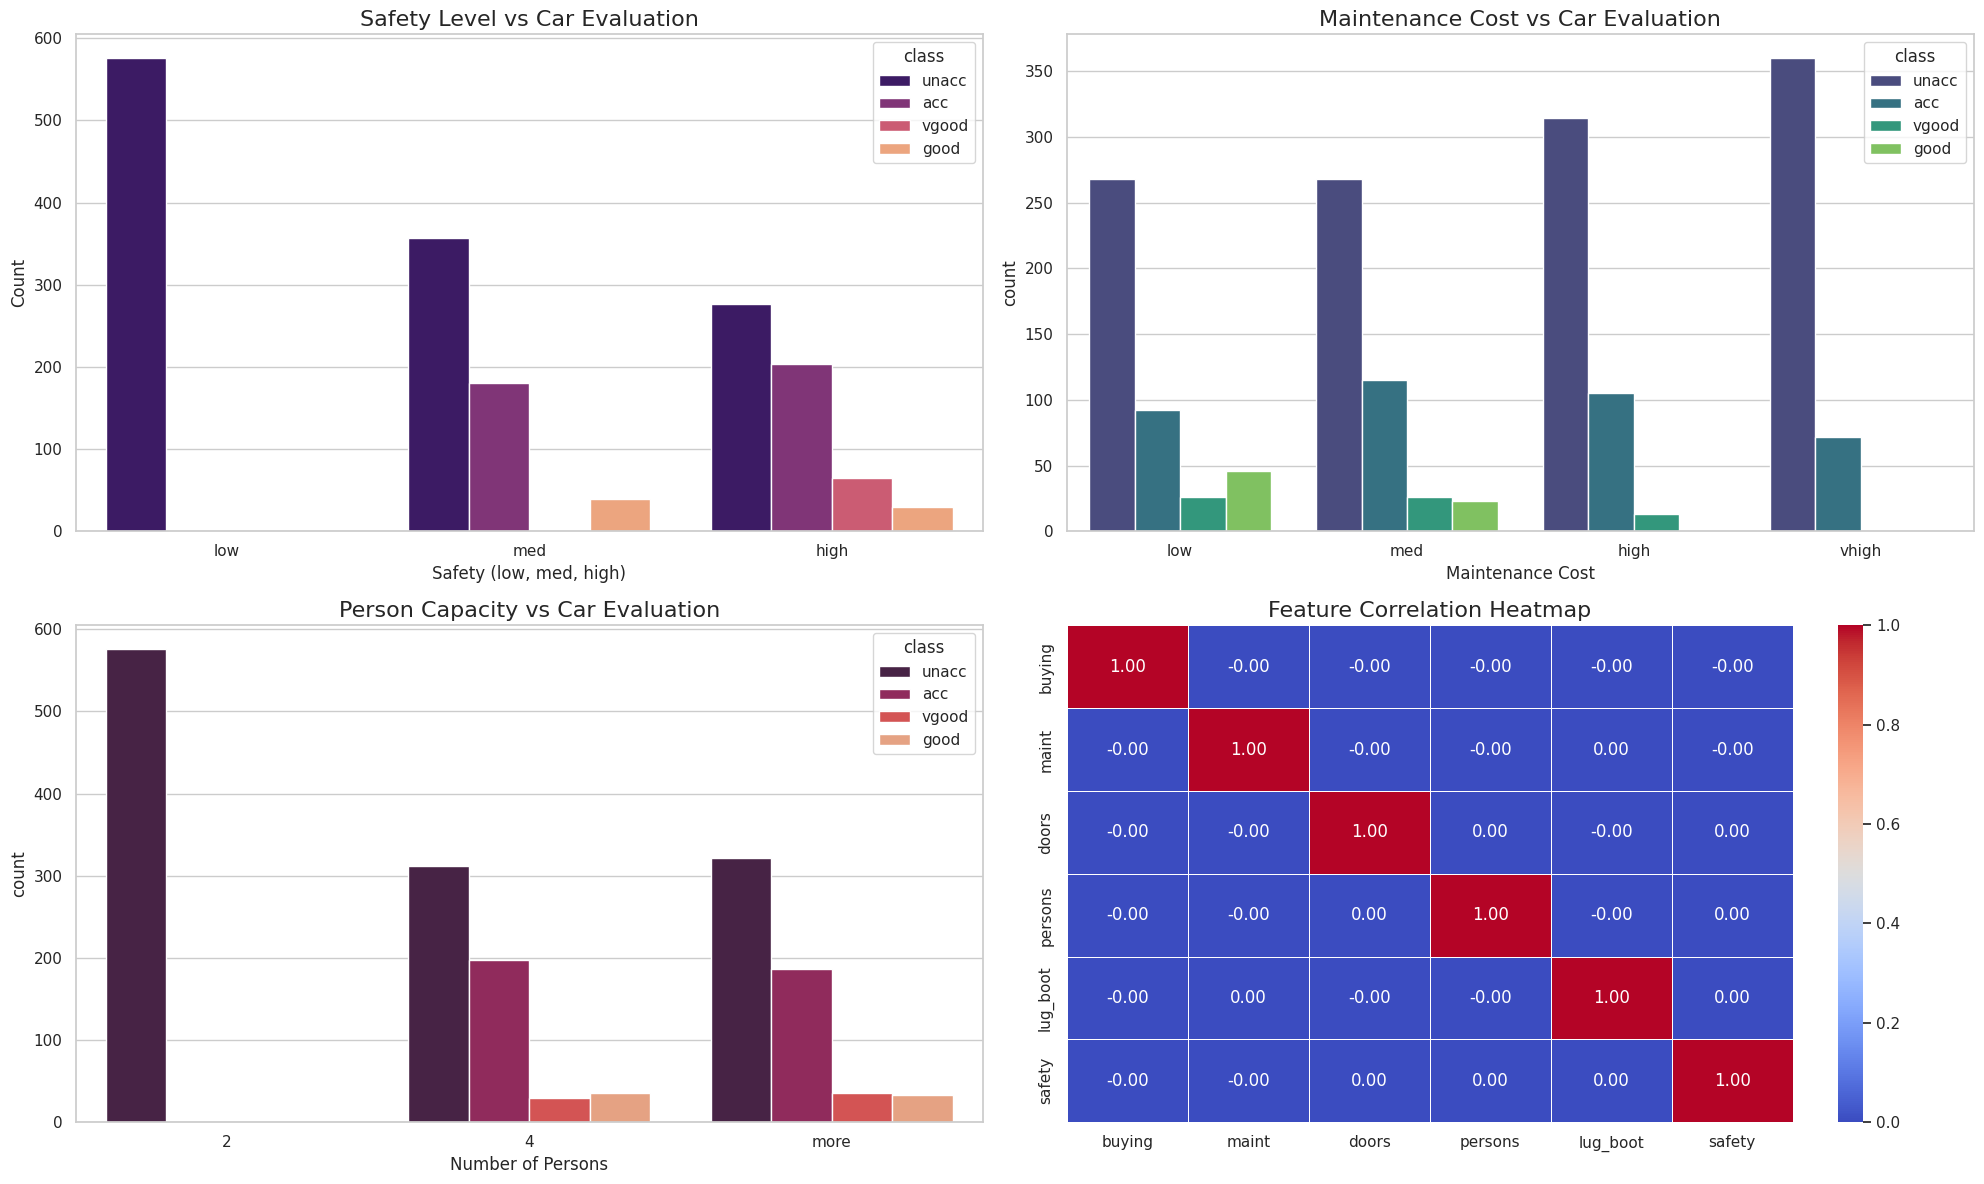

In [5]:
# Setting up a larger grid for additional insights
plt.figure(figsize=(20, 12))

# Graph 1: Impact of Safety on Evaluation
# I am using a countplot with a hue to show how safety levels strictly dictate the 'unacc' class
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='safety', hue='class', palette='magma')
plt.title('Safety Level vs Car Evaluation', fontsize=16)
plt.xlabel('Safety (low, med, high)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Graph 2: Maintenance Cost vs Evaluation
# I want to see if high maintenance cars are more likely to be unacceptable
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='maint', hue='class', palette='viridis',
              order=['low', 'med', 'high', 'vhigh'])
plt.title('Maintenance Cost vs Car Evaluation', fontsize=16)
plt.xlabel('Maintenance Cost', fontsize=12)

# Graph 3: Person Capacity vs Evaluation
# I am analyzing how the 'persons' attribute affects the rating
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='persons', hue='class', palette='rocket')
plt.title('Person Capacity vs Car Evaluation', fontsize=16)
plt.xlabel('Number of Persons', fontsize=12)

# Graph 4: Correlation Heatmap of Features
# Note: I am using the X_encoded dataframe created in the preprocessing step
# to show the relationship between numerical categorical values
plt.subplot(2, 2, 4)
correlation = X_encoded.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipython-input-919109129.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_encoded[y_encoded == target_class][col],


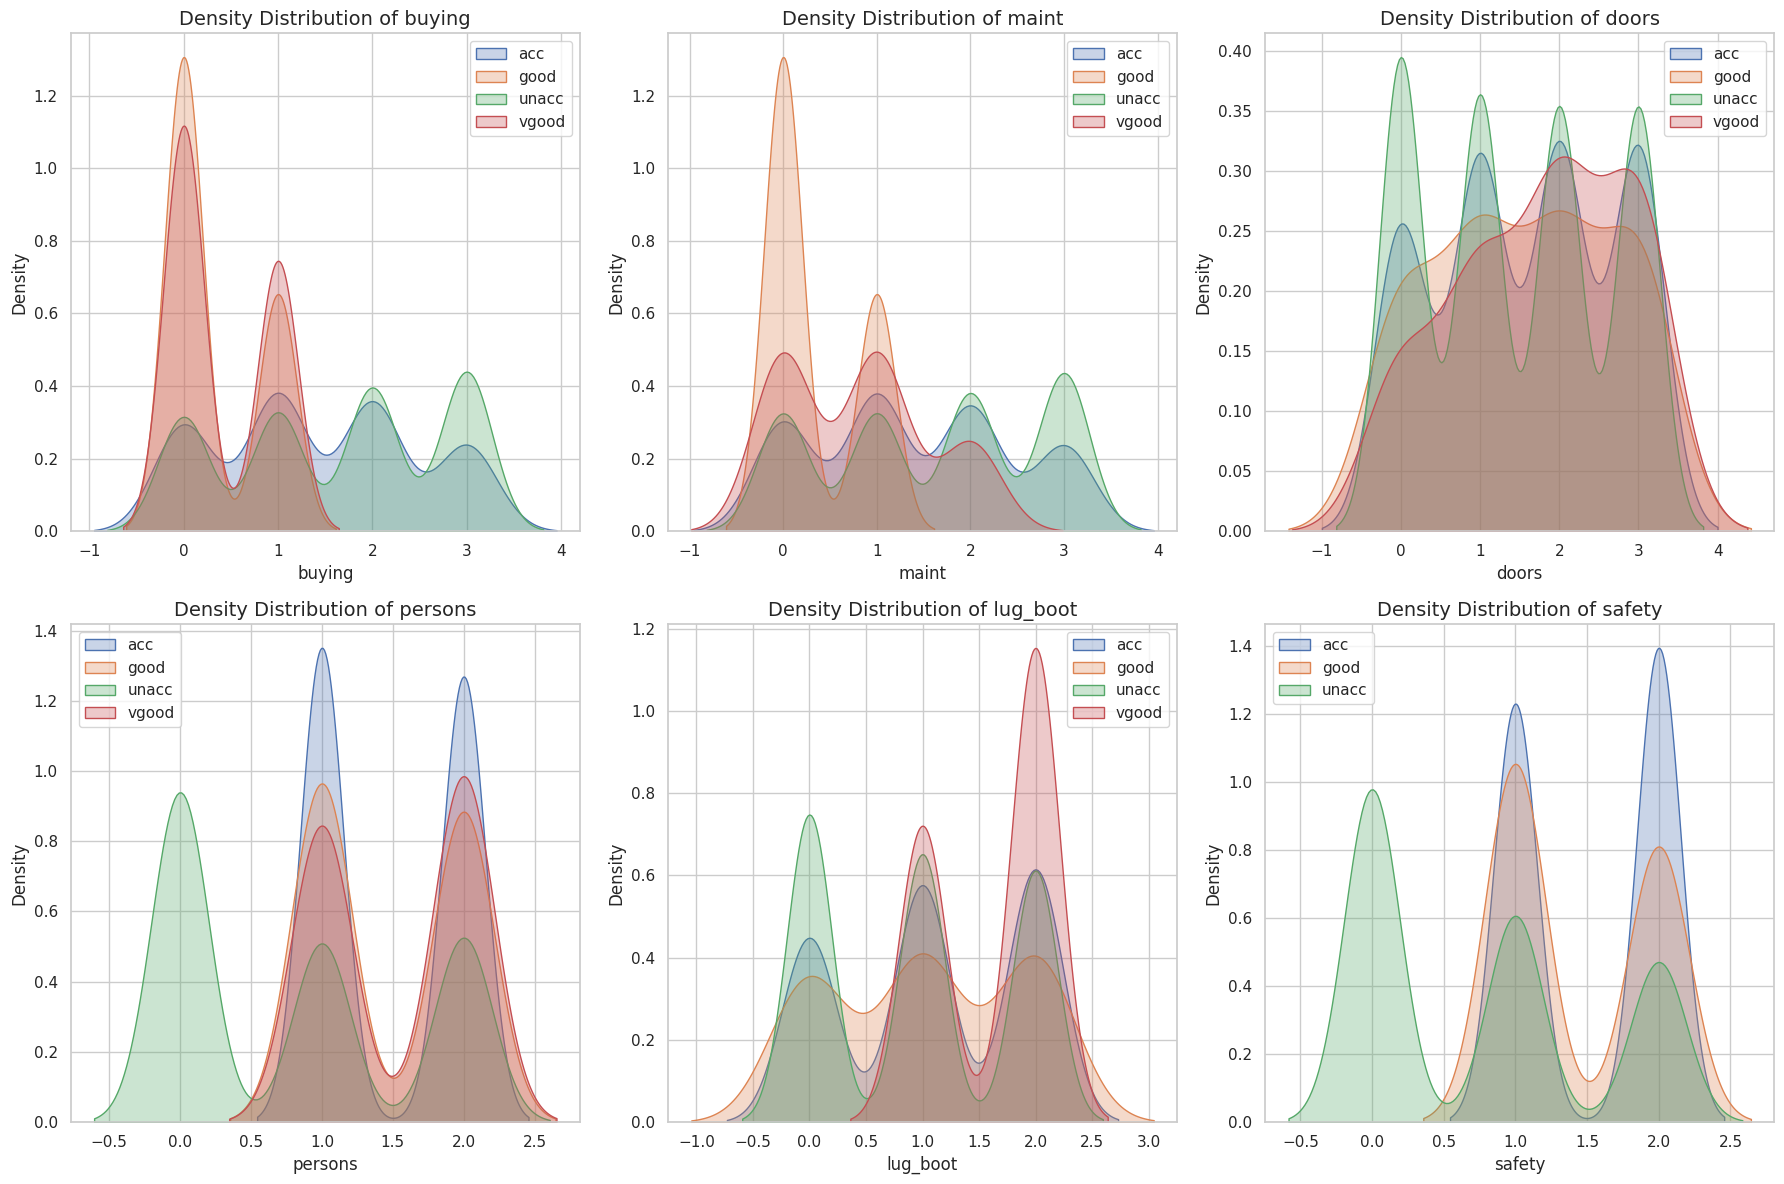

In [7]:
# 1. Density Plot (KDE) for all features class-wise
# I am creating a multi-panel density plot to see the probability distribution of each attribute
plt.figure(figsize=(18, 12))
features = X_encoded.columns

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    for target_class in np.unique(y_encoded):
        sns.kdeplot(X_encoded[y_encoded == target_class][col],
                    label=le.inverse_transform([target_class])[0],
                    fill=True, common_norm=False, alpha=0.3)
    plt.title(f'Density Distribution of {col}', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()


# **Data Preprocessing and Splitting**
I convert the categorical text into ordered numerical values using OrdinalEncoder. I also split the data into an 80/20 ratio for training and testing.

In [3]:
# Separating Features and Target
X = df.drop(['class'], axis=1)
y = df['class']

# Defining order for features
order = [['low', 'med', 'high', 'vhigh'], ['low', 'med', 'high', 'vhigh'],
         ['2', '3', '4', '5more'], ['2', '4', 'more'],
         ['small', 'med', 'big'], ['low', 'med', 'high']]

# Encoding features and target
X_encoded = pd.DataFrame(OrdinalEncoder(categories=order).fit_transform(X), columns=X.columns)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print("Preprocessing and Splitting finished.")

Preprocessing and Splitting finished.
